In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import glob

input_path = '/content/drive/MyDrive/SC_Dataset'
df = pd.read_csv(os.path.join(input_path, 'HAM10000_metadata.csv'))

all_images = glob.glob(input_path + '/HAM10000_images_part_*/*.jpg')
image_path_map = {}
for p in all_images:
    image_id = p.split('/')[-1].replace('.jpg', '')
    image_path_map[image_id] = p

df['path'] = df['image_id'].map(image_path_map)
df = df[['lesion_id', 'image_id', 'dx', 'path']]

print(f"Total images : {len(df)}")
print(f"Missing paths: {df['path'].isna().sum()}")
print(df['dx'].value_counts())

Total images : 10015
Missing paths: 0
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

lesions = df['lesion_id'].unique()
train_lesions, temp_lesions = train_test_split(
    lesions, test_size=0.3, random_state=42
)
val_lesions, test_lesions = train_test_split(
    temp_lesions, test_size=0.5, random_state=42
)

train_df = df[df['lesion_id'].isin(train_lesions)]
val_df   = df[df['lesion_id'].isin(val_lesions)]
test_df  = df[df['lesion_id'].isin(test_lesions)]

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

print("\nTrain class distribution:")
print(train_df['dx'].value_counts())
print("\nVal class distribution:")
print(val_df['dx'].value_counts())
print("\nTest class distribution:")
print(test_df['dx'].value_counts())

Train : 6987
Val   : 1512
Test  : 1516

Train class distribution:
dx
nv       4728
mel       775
bkl       734
bcc       355
akiec     235
vasc       85
df         75
Name: count, dtype: int64

Val class distribution:
dx
nv       958
mel      193
bkl      180
bcc       82
vasc      41
akiec     41
df        17
Name: count, dtype: int64

Test class distribution:
dx
nv       1019
bkl       185
mel       145
bcc        77
akiec      51
df         23
vasc       16
Name: count, dtype: int64


In [ ]:
target_count    = 500
oversampled_dfs = []

for cls in train_df['dx'].unique():
    cls_df  = train_df[train_df['dx'] == cls]
    current = len(cls_df)

    if current < target_count:
        extra_df = cls_df.sample(
            n            = target_count - current,
            replace      = True,
            random_state = 42
        )
        cls_df = pd.concat([cls_df, extra_df])
        print(f"{cls}: {current} → {len(cls_df)} images (oversampled)")
    else:
        print(f"{cls}: {current} images — no oversampling needed")

    oversampled_dfs.append(cls_df)

train_df_balanced = (pd.concat(oversampled_dfs)
                       .sample(frac=1, random_state=42)
                       .reset_index(drop=True))

print(f"\nBalanced train size: {len(train_df_balanced)}")
print(train_df_balanced['dx'].value_counts())

bkl: 734 images — no oversampling needed
nv: 4728 images — no oversampling needed
df: 75 → 500 images (oversampled)
mel: 775 images — no oversampling needed
vasc: 85 → 500 images (oversampled)
bcc: 355 → 500 images (oversampled)
akiec: 235 → 500 images (oversampled)

Balanced train size: 8237
dx
nv       4728
mel       775
bkl       734
df        500
akiec     500
vasc      500
bcc       500
Name: count, dtype: int64


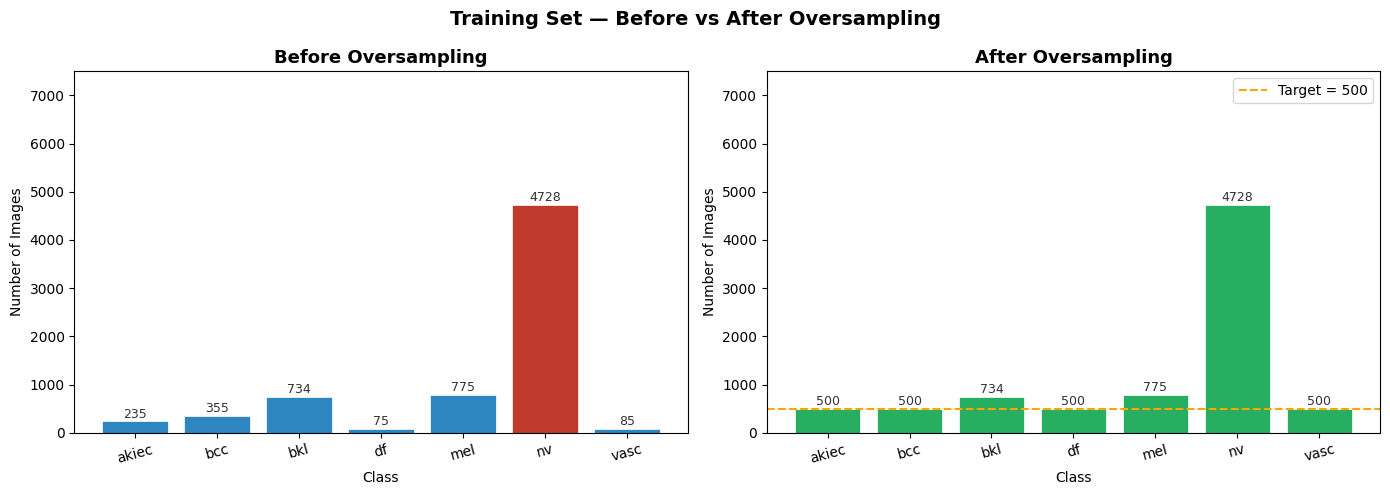

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────
before = train_df['dx'].value_counts().sort_index()
after  = train_df_balanced['dx'].value_counts().sort_index()
classes = before.index.tolist()

# ── Figure 1: Side-by-side bar chart ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Set — Before vs After Oversampling', fontsize=14, fontweight='bold')

colors_before = ['#C0392B' if c == 'nv' else '#2E86C1' for c in classes]
colors_after  = ['#27AE60' for _ in classes]

axes[0].bar(classes, before.values, color=colors_before, edgecolor='white', linewidth=0.5)
axes[0].set_title('Before Oversampling', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, 7500)
for i, v in enumerate(before.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontsize=9, color='#333333')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(classes, after.values, color=colors_after, edgecolor='white', linewidth=0.5)
axes[1].set_title('After Oversampling', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Images')
axes[1].set_ylim(0, 7500)
for i, v in enumerate(after.values):
    axes[1].text(i, v + 80, str(v), ha='center', fontsize=9, color='#333333')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=500, color='orange', linestyle='--', linewidth=1.5, label='Target = 500')
axes[1].legend()

plt.tight_layout()
plt.savefig('oversampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_labels = sorted(train_df['dx'].unique())

weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array(class_labels),
    y            = train_df['dx'].values
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)

print("Class | Weight")
for cls, w in zip(class_labels, weights):
    print(f"  {cls:<8} → {w:.4f}")

Device: cuda
Class | Weight
  akiec    → 4.2474
  bcc      → 2.8117
  bkl      → 1.3599
  df       → 13.3086
  mel      → 1.2879
  nv       → 0.2111
  vasc     → 11.7429


In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch

# Global — same indices across all splits
LABEL_MAP = {
    'akiec': 0,
    'bcc':   1,
    'bkl':   2,
    'df':    3,
    'mel':   4,
    'nv':    5,
    'vasc':  6
}

class SkinLesionDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        super().__init__()
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path  = self.dataframe.loc[idx, 'path']
        image     = Image.open(img_path).convert('RGB')
        label_str = self.dataframe.loc[idx, 'dx']

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(LABEL_MAP[label_str], dtype=torch.long)
        return image, label


train_dataset = SkinLesionDataset(train_df_balanced, transform=train_transforms)
val_dataset   = SkinLesionDataset(val_df,            transform=val_test_transforms)
test_dataset  = SkinLesionDataset(test_df,           transform=val_test_transforms)


image, label = train_dataset[0]
print(f"Image shape : {image.shape}")
print(f"Label       : {label}")
print(f"Label dtype : {label.dtype}")
print(f"Train size  : {len(train_dataset)}")
print(f"Val size    : {len(val_dataset)}")
print(f"Test size   : {len(test_dataset)}")

Image shape : torch.Size([3, 300, 300])
Label       : 2
Label dtype : torch.int64
Train size  : 8237
Val size    : 1512
Test size   : 1516


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


Train batches : 258
Val batches   : 48
Test batches  : 48


In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
import pandas as pd
import copy

def train_model(model, model_name, train_loader, val_loader,epochs, lr, class_weights=None):
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device)

    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
        print("Using weighted CrossEntropyLoss")
    else:
        criterion = nn.CrossEntropyLoss()
        print("Using standard CrossEntropyLoss")

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'val_f1':     []
    }

    best_val_loss  = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs} | "
              f"LR: {optimizer.param_groups[0]['lr']:.8f}")

        #TRAINING
        model.train()
        train_loss = 0.0
        train_true, train_pred = [], []

        for inputs, labels in tqdm(train_loader, desc="Train"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            train_true.extend(labels.detach().cpu().numpy())
            train_pred.extend(preds.detach().cpu().numpy())

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_acc      = accuracy_score(train_true, train_pred)

        #VALIDATION
        model.eval()
        val_loss = 0.0
        val_true, val_pred = [], []

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc="Val"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                logits = model(inputs)
                loss   = criterion(logits, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(logits, dim=1)
                val_true.extend(labels.detach().cpu().numpy())
                val_pred.extend(preds.detach().cpu().numpy())

        avg_val_loss = val_loss / len(val_loader.dataset)
        val_acc      = accuracy_score(val_true, val_pred)
        val_f1       = f1_score(val_true, val_pred,
                                average='weighted', zero_division=0)

        #SCHEDULER
        scheduler.step()

        #SAVE BEST
        if avg_val_loss < best_val_loss:
            best_val_loss  = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss':             avg_val_loss,
                'val_acc':              val_acc
            }, f'best_{model_name}.pt')
            print(f"  ✓ Saved best model")

        #STORE
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"  Train → Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"  Val   → Loss: {avg_val_loss:.4f} | "
              f"Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    model.load_state_dict(best_model_wts)
    print(f"\nDone — {model_name} | Best Val Loss: {best_val_loss:.4f}")
    return model, pd.DataFrame(history)

In [ ]:
import torch.nn as nn
import matplotlib.pyplot as plt

class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # 300→150

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # 150→75

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # flatten = 128 × 1 × 1 = 128
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
cnn_model = CustomCNN(num_classes=7)

trained_cnn, cnn_history = train_model(
    model         = cnn_model,
    model_name    = "CustomCNN",
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 35,
    lr            = 0.001,
    class_weights = class_weights_tensor
)

Training: CustomCNN
Using weighted CrossEntropyLoss

Epoch 1/35 | LR: 0.00100000


Val: 100%|██████████| 48/48 [00:20<00:00,  2.33it/s]


  ✓ Saved best model
  Train → Loss: 1.6059 | Acc: 0.0981
  Val   → Loss: 2.3473 | Acc: 0.0542 | F1: 0.0761

Epoch 2/35 | LR: 0.00099799


Val: 100%|██████████| 48/48 [00:20<00:00,  2.38it/s]


  ✓ Saved best model
  Train → Loss: 1.4639 | Acc: 0.1826
  Val   → Loss: 2.3217 | Acc: 0.0992 | F1: 0.1384

Epoch 3/35 | LR: 0.00099197


...

  Train → Loss: 0.9668 | Acc: 0.4040
  Val   → Loss: 1.3773 | Acc: 0.4438 | F1: 0.5099

Epoch 34/35 | LR: 0.00000903


Val: 100%|██████████| 48/48 [00:19<00:00,  2.46it/s]


  Train → Loss: 0.9615 | Acc: 0.4065
  Val   → Loss: 1.4026 | Acc: 0.4378 | F1: 0.5057

Epoch 35/35 | LR: 0.00000301


Val: 100%|██████████| 48/48 [00:19<00:00,  2.46it/s]

  Train → Loss: 0.9652 | Acc: 0.4008
  Val   → Loss: 1.3536 | Acc: 0.4438 | F1: 0.5099

Done — CustomCNN | Best Val Loss: 1.3073


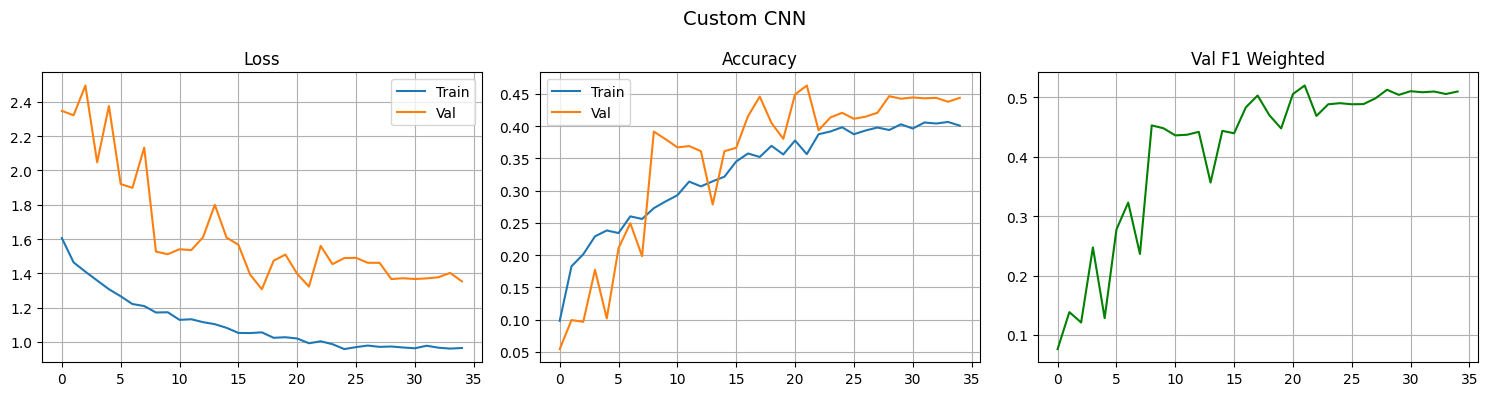

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Custom CNN', fontsize=14)

axes[0].plot(cnn_history['train_loss'], label='Train')
axes[0].plot(cnn_history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(cnn_history['train_acc'], label='Train')
axes[1].plot(cnn_history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(cnn_history['val_f1'], color='green')
axes[2].set_title('Val F1 Weighted')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt

resnet_model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)

# Freeze all
for param in resnet_model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

num_features = resnet_model.fc.in_features   # 2048
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Linear(256, 7)
)

trainable = sum(p.numel() for p in resnet_model.parameters()
                if p.requires_grad)
total     = sum(p.numel() for p in resnet_model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}")


Trainable: 15,491,079 / Total: 24,034,375


In [ ]:
# ── Train ─────────────────────────────────────
trained_resnet, resnet_history = train_model(
    model         = resnet_model,
    model_name    = "ResNet50",
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 35,
    lr            = 0.0001,        # smaller lr for pretrained
    class_weights = class_weights_tensor
)


Training: ResNet50
Using weighted CrossEntropyLoss

Epoch 1/35 | LR: 0.00010000


Val: 100%|██████████| 48/48 [00:26<00:00,  1.81it/s]


  ✓ Saved best model
  Train → Loss: 0.7645 | Acc: 0.4141
  Val   → Loss: 0.9044 | Acc: 0.6700 | F1: 0.6996

Epoch 2/35 | LR: 0.00009980


Val: 100%|██████████| 48/48 [00:26<00:00,  1.80it/s]


  Train → Loss: 0.4374 | Acc: 0.6648
  Val   → Loss: 1.0810 | Acc: 0.6488 | F1: 0.6843

Epoch 3/35 | LR: 0.00009920


...

  Train → Loss: 0.0482 | Acc: 0.9280
  Val   → Loss: 0.7534 | Acc: 0.8241 | F1: 0.8213

Epoch 34/35 | LR: 0.00000180


Val: 100%|██████████| 48/48 [00:27<00:00,  1.72it/s]


  Train → Loss: 0.0478 | Acc: 0.9198
  Val   → Loss: 0.7617 | Acc: 0.8142 | F1: 0.8151

Epoch 35/35 | LR: 0.00000120


Val: 100%|██████████| 48/48 [00:27<00:00,  1.73it/s]

  Train → Loss: 0.0479 | Acc: 0.9213
  Val   → Loss: 0.7498 | Acc: 0.8208 | F1: 0.8200

Done — ResNet50 | Best Val Loss: 0.6958


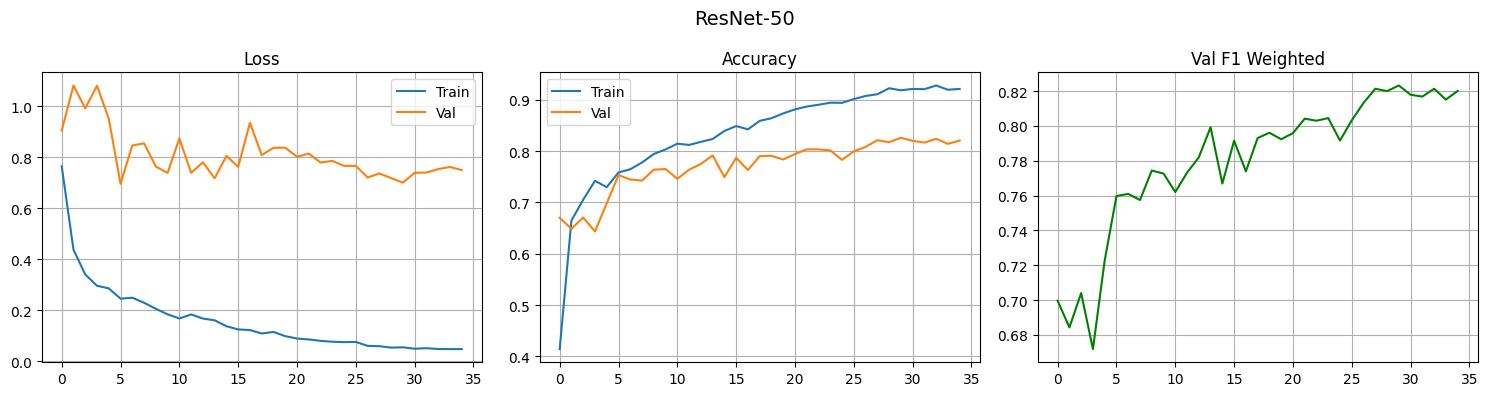

In [ ]:
# ── Plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ResNet-50', fontsize=14)

axes[0].plot(resnet_history['train_loss'], label='Train')
axes[0].plot(resnet_history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(resnet_history['train_acc'], label='Train')
axes[1].plot(resnet_history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(resnet_history['val_f1'], color='green')
axes[2].set_title('Val F1 Weighted')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt

eff_model = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

# Freeze all
for param in eff_model.parameters():
    param.requires_grad = False


for param in eff_model.features[-3:].parameters():
    param.requires_grad = True

in_features = eff_model.classifier[1].in_features
eff_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Linear(256, 7)
)

trainable = sum(p.numel() for p in eff_model.parameters()
                if p.requires_grad)
total     = sum(p.numel() for p in eff_model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}")





Trainable: 8,901,349 / Total: 11,091,503


In [ ]:
# ── Train ─────────────────────────────────────
trained_eff, eff_history = train_model(
    model         = eff_model,
    model_name    = "EfficientNet_B3",
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 35,
    lr            = 0.0001,
    class_weights = class_weights_tensor
)

Training: EfficientNet_B3
Using weighted CrossEntropyLoss

Epoch 1/35 | LR: 0.00010000


Val: 100%|██████████| 48/48 [00:25<00:00,  1.88it/s]


  ✓ Saved best model
  Train → Loss: 1.0582 | Acc: 0.2780
  Val   → Loss: 1.3039 | Acc: 0.5357 | F1: 0.5759

Epoch 2/35 | LR: 0.00009980


Val: 100%|██████████| 48/48 [00:25<00:00,  1.86it/s]


  ✓ Saved best model
  Train → Loss: 0.4673 | Acc: 0.6377
  Val   → Loss: 0.9583 | Acc: 0.6409 | F1: 0.6743

Epoch 3/35 | LR: 0.00009920


...

  Train → Loss: 0.0795 | Acc: 0.8943
  Val   → Loss: 0.6452 | Acc: 0.7976 | F1: 0.8039

Epoch 34/35 | LR: 0.00000180


Val: 100%|██████████| 48/48 [00:25<00:00,  1.88it/s]


  Train → Loss: 0.0740 | Acc: 0.8943
  Val   → Loss: 0.6275 | Acc: 0.8049 | F1: 0.8120

Epoch 35/35 | LR: 0.00000120


Val: 100%|██████████| 48/48 [00:25<00:00,  1.87it/s]

  Train → Loss: 0.0786 | Acc: 0.8926
  Val   → Loss: 0.6375 | Acc: 0.8056 | F1: 0.8101

Done — EfficientNet_B3 | Best Val Loss: 0.5912


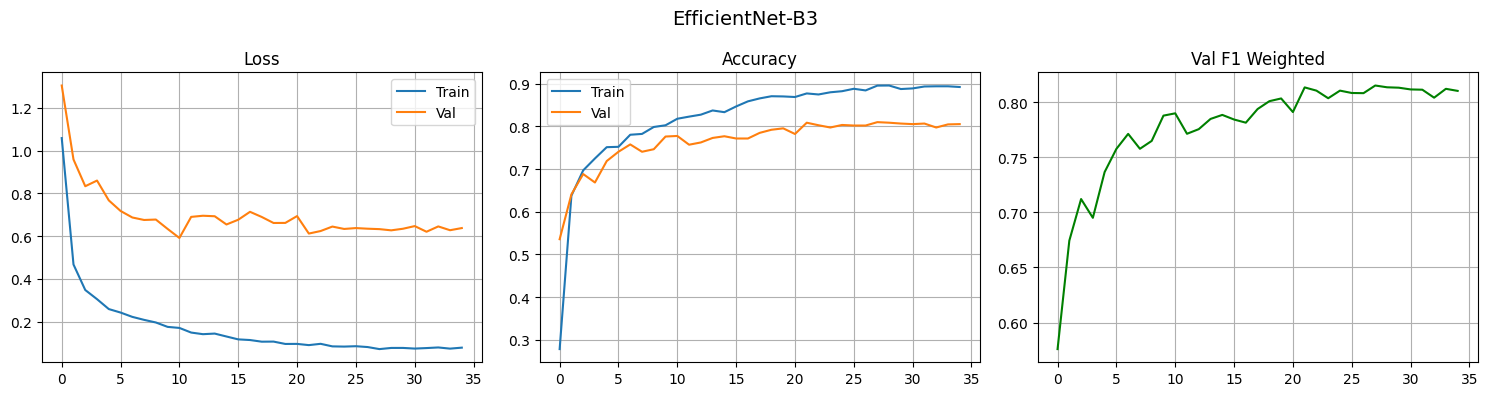

In [ ]:
# ── Plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EfficientNet-B3', fontsize=14)

axes[0].plot(eff_history['train_loss'], label='Train')
axes[0].plot(eff_history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(eff_history['train_acc'], label='Train')
axes[1].plot(eff_history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(eff_history['val_f1'], color='green')
axes[2].set_title('Val F1 Weighted')
axes[2].grid(True)

plt.tight_layout()
plt.show()

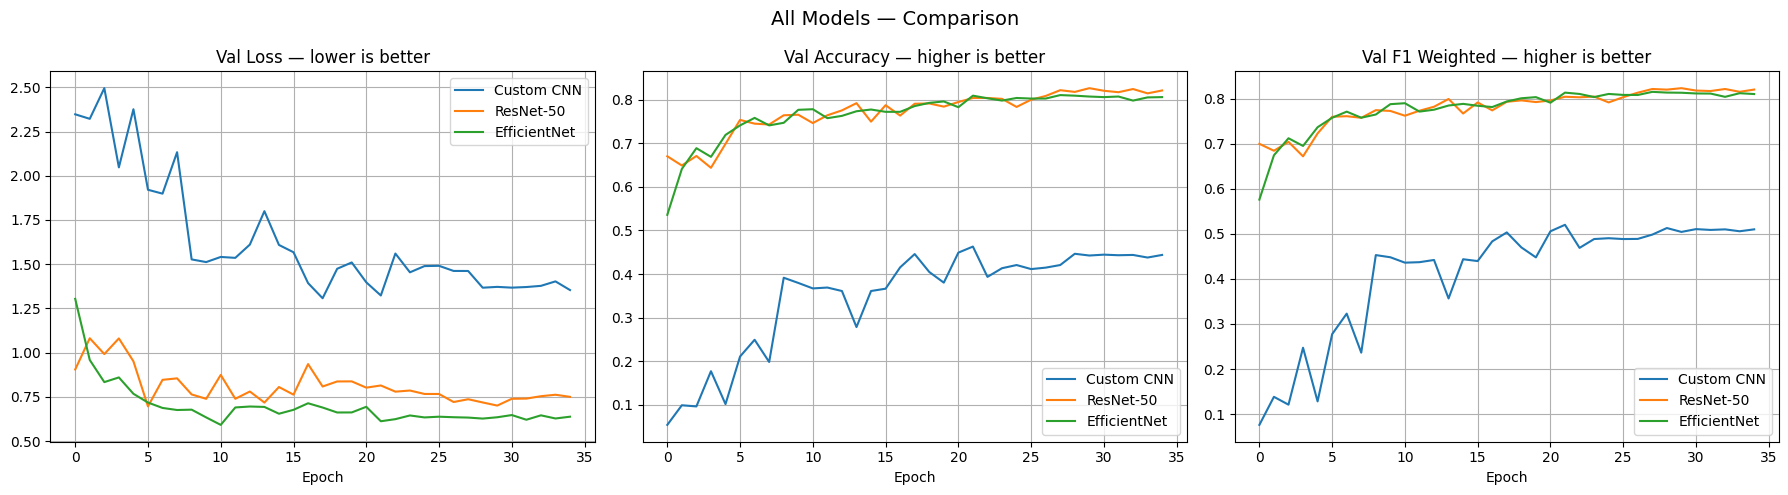

In [ ]:
import matplotlib.pyplot as plt

histories = {
    'Custom CNN':   cnn_history,
    'ResNet-50':    resnet_history,
    'EfficientNet': eff_history
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('All Models — Comparison', fontsize=14)

for name, h in histories.items():
    axes[0].plot(h['val_loss'], label=name)
    axes[1].plot(h['val_acc'],  label=name)
    axes[2].plot(h['val_f1'],   label=name)

axes[0].set_title('Val Loss — lower is better')
axes[1].set_title('Val Accuracy — higher is better')
axes[2].set_title('Val F1 Weighted — higher is better')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

  TEST RESULTS — CustomCNN
  Accuracy        : 0.4261
  Weighted F1     : 0.4942
  Macro F1        : 0.2215
  Weighted Precision : 0.7506
  Weighted Recall    : 0.4261
  ROC-AUC (OvR)   : 0.8458

Per-Class Report:
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        51
         bcc       0.33      0.05      0.09        77
         bkl       0.52      0.09      0.16       185
          df       0.04      0.78      0.08        23
         mel       0.24      0.68      0.35       145
          nv       0.96      0.48      0.64      1019
        vasc       0.13      0.88      0.23        16

    accuracy                           0.43      1516
   macro avg       0.32      0.42      0.22      1516
weighted avg       0.75      0.43      0.49      1516



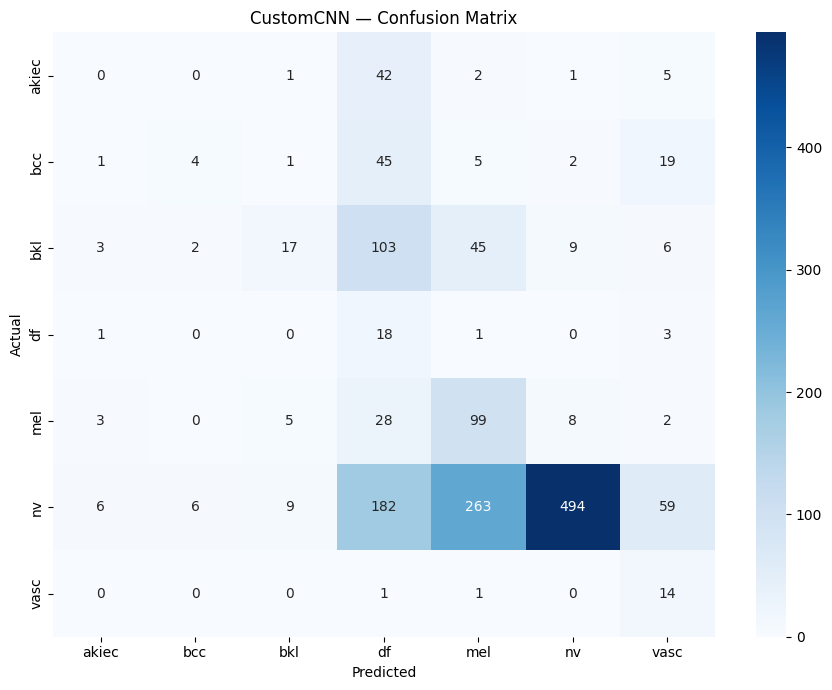

  TEST RESULTS — ResNet50
  Accuracy        : 0.7612
  Weighted F1     : 0.7732
  Macro F1        : 0.5862
  Weighted Precision : 0.7968
  Weighted Recall    : 0.7612
  ROC-AUC (OvR)   : 0.9332

Per-Class Report:
              precision    recall  f1-score   support

       akiec       0.37      0.67      0.48        51
         bcc       0.61      0.82      0.70        77
         bkl       0.56      0.62      0.59       185
          df       0.43      0.39      0.41        23
         mel       0.48      0.51      0.50       145
          nv       0.93      0.83      0.88      1019
        vasc       0.39      0.94      0.56        16

    accuracy                           0.76      1516
   macro avg       0.54      0.68      0.59      1516
weighted avg       0.80      0.76      0.77      1516



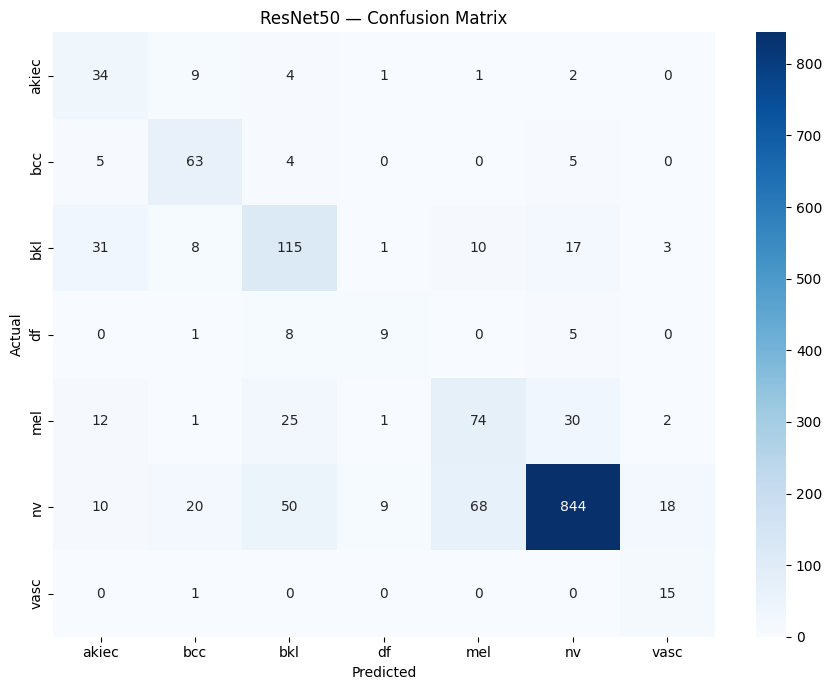

  TEST RESULTS — EfficientNet
  Accuracy        : 0.7592
  Weighted F1     : 0.7797
  Macro F1        : 0.6709
  Weighted Precision : 0.8202
  Weighted Recall    : 0.7592
  ROC-AUC (OvR)   : 0.9509

Per-Class Report:
              precision    recall  f1-score   support

       akiec       0.46      0.65      0.54        51
         bcc       0.71      0.71      0.71        77
         bkl       0.61      0.68      0.64       185
          df       0.67      0.61      0.64        23
         mel       0.35      0.66      0.46       145
          nv       0.96      0.80      0.87      1019
        vasc       0.75      0.94      0.83        16

    accuracy                           0.76      1516
   macro avg       0.64      0.72      0.67      1516
weighted avg       0.82      0.76      0.78      1516



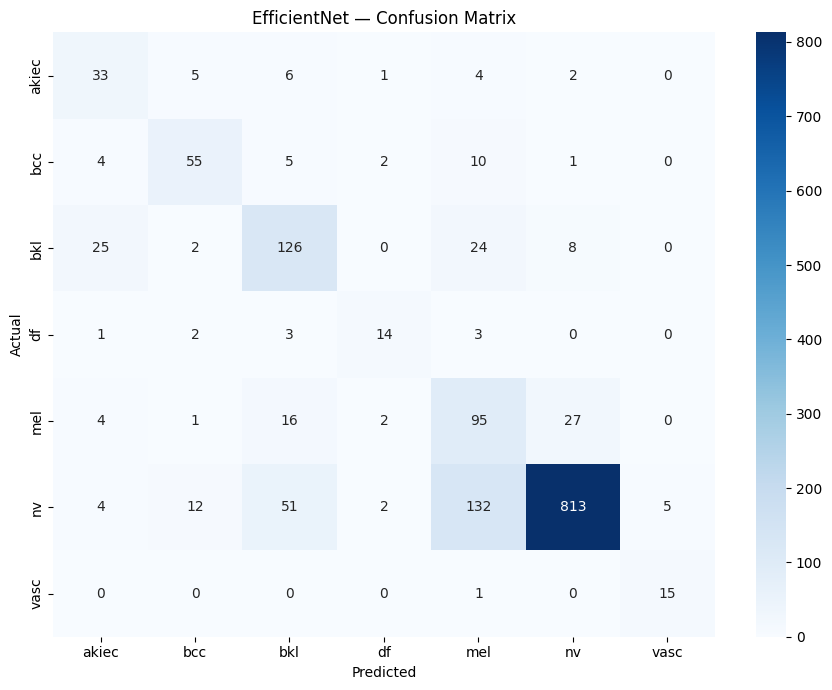

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

def evaluate_model(model, test_loader, model_name, device):

    model.eval()
    y_true  = []
    y_pred  = []
    y_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs  = inputs.to(device)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            preds   = torch.argmax(probs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_probs = np.array(y_probs)

    # ── Overall Metrics ──────────────────────────────────────
    accuracy   = accuracy_score(y_true, y_pred)
    f1_weighted = f1_score(y_true, y_pred,average='weighted', zero_division=0)
    f1_macro   = f1_score(y_true, y_pred,average='macro', zero_division=0)
    precision  = precision_score(y_true, y_pred,average='weighted', zero_division=0)
    recall     = recall_score(y_true, y_pred,average='weighted', zero_division=0)
    roc_auc    = roc_auc_score(y_true, y_probs,multi_class='ovr', average='macro')


    print(f"  TEST RESULTS — {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy        : {accuracy:.4f}")
    print(f"  Weighted F1     : {f1_weighted:.4f}")
    print(f"  Macro F1        : {f1_macro:.4f}")
    print(f"  Weighted Precision : {precision:.4f}")
    print(f"  Weighted Recall    : {recall:.4f}")
    print(f"  ROC-AUC (OvR)   : {roc_auc:.4f}")
    print(f"{'='*55}")

    # ── Per Class Breakdown ───────────────────────────────────
    print(f"\nPer-Class Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        zero_division=0
    ))

    # ── Confusion Matrix ──────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm,
        annot      = True,
        fmt        = 'd',
        cmap       = 'Blues',
        xticklabels = class_names,
        yticklabels = class_names
    )
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {
        'accuracy':    accuracy,
        'f1_weighted': f1_weighted,
        'f1_macro':    f1_macro,
        'precision':   precision,
        'recall':      recall,
        'roc_auc':     roc_auc
    }

# ── Evaluate All Three ────────────────────────────────────────
cnn_metrics    = evaluate_model(trained_cnn,    test_loader,
                                "CustomCNN",    device)
resnet_metrics = evaluate_model(trained_resnet, test_loader,
                                "ResNet50",     device)
eff_metrics    = evaluate_model(trained_eff,    test_loader,
                                "EfficientNet", device)

In [ ]:
# Compare all three models side by side
print(f"\n{'='*65}")
print(f"  FINAL MODEL COMPARISON")
print(f"{'='*65}")
print(f"  {'Metric':<20} {'CNN':>10} {'ResNet':>10} {'EfficientNet':>14}")
print(f"  {'-'*60}")

metrics_to_show = [
    ('Accuracy',    'accuracy'),
    ('F1 Weighted', 'f1_weighted'),
    ('F1 Macro',    'f1_macro'),
    ('Precision',   'precision'),
    ('Recall',      'recall'),
    ('ROC-AUC',     'roc_auc')
]

for label, key in metrics_to_show:
    cnn_val = cnn_metrics[key]
    res_val = resnet_metrics[key]
    eff_val = eff_metrics[key]
    print(f"  {label:<20} {cnn_val:>10.4f} {res_val:>10.4f} {eff_val:>14.4f}")

print(f"{'='*65}")


  FINAL MODEL COMPARISON
  Metric                      CNN     ResNet   EfficientNet
  ------------------------------------------------------------
  Accuracy                 0.4261     0.7612         0.7592
  F1 Weighted              0.4942     0.7732         0.7797
  F1 Macro                 0.2215     0.5862         0.6709
  Precision                0.7506     0.7968         0.8202
  Recall                   0.4261     0.7612         0.7592
  ROC-AUC                  0.8458     0.9332         0.9509
